# 📈 Yahoo Stock Price Forecasting Project
### Author: Md. Murad Hossain
This project uses the **Facebook Prophet** library to forecast future stock prices based on historical data from Yahoo Finance.

**Key Features:**
* Time-series analysis and stationarity testing (ADF Test).
* Incorporating country-specific holidays.
* Hyperparameter tuning for optimal performance.
* Model evaluation using Cross-Validation and MAPE.

In [5]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mounting Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Load the dataset
file_path = '/content/drive/MyDrive/csv/yahoo_stock.csv'
df = pd.read_csv(file_path)

df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [7]:
# Prepare data for Prophet (Date -> ds, Close -> y)
df_final = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
df_final['ds'] = pd.to_datetime(df_final['ds'])

print("Dataset Preview:")
display(df_final.head())

Dataset Preview:


,ds,y
0,2015-11-23,2086.590088
1,2015-11-24,2089.139893
2,2015-11-25,2088.870117
3,2015-11-26,2088.870117
4,2015-11-27,2090.110107


ADF Statistic: -0.8703973870161453
p-value: 0.7975646340657463
Result: Data is Non-Stationary (Trend exists)


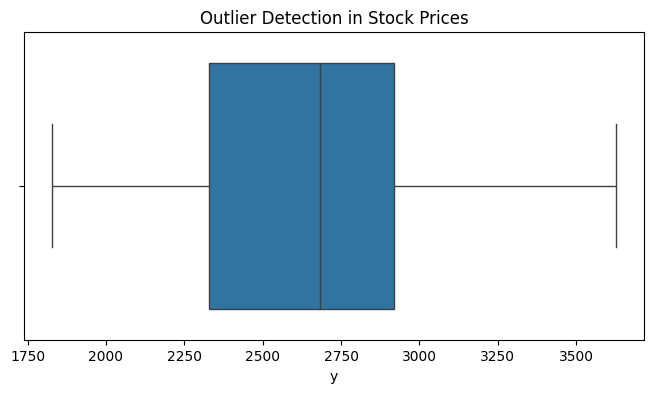

In [8]:
# Stationarity Test (ADF)
result = adfuller(df_final['y'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Result: Data is Stationary")
else:
    print("Result: Data is Non-Stationary (Trend exists)")

# Outlier Detection
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_final['y'])
plt.title('Outlier Detection in Stock Prices')
plt.show()

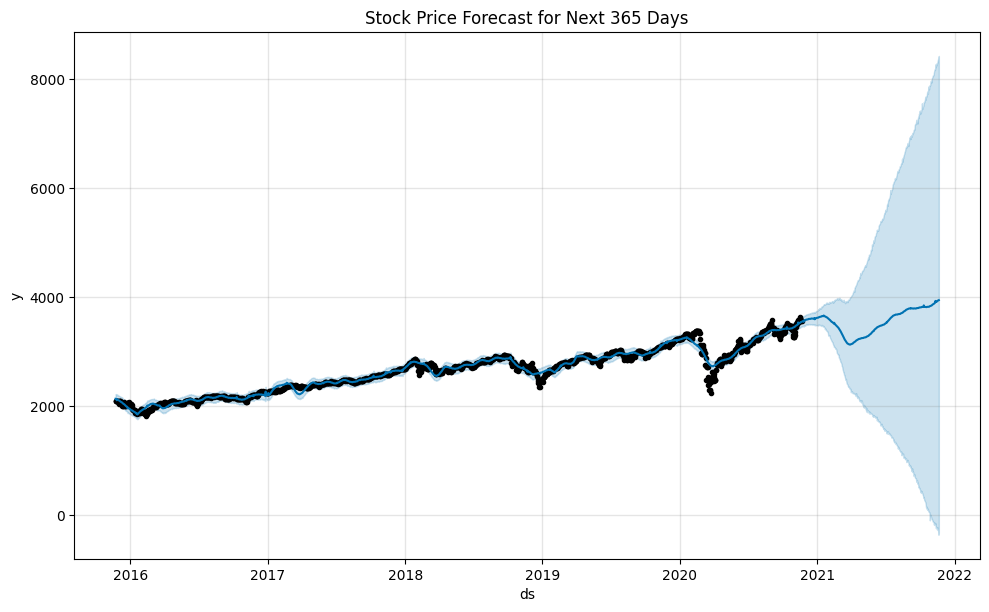

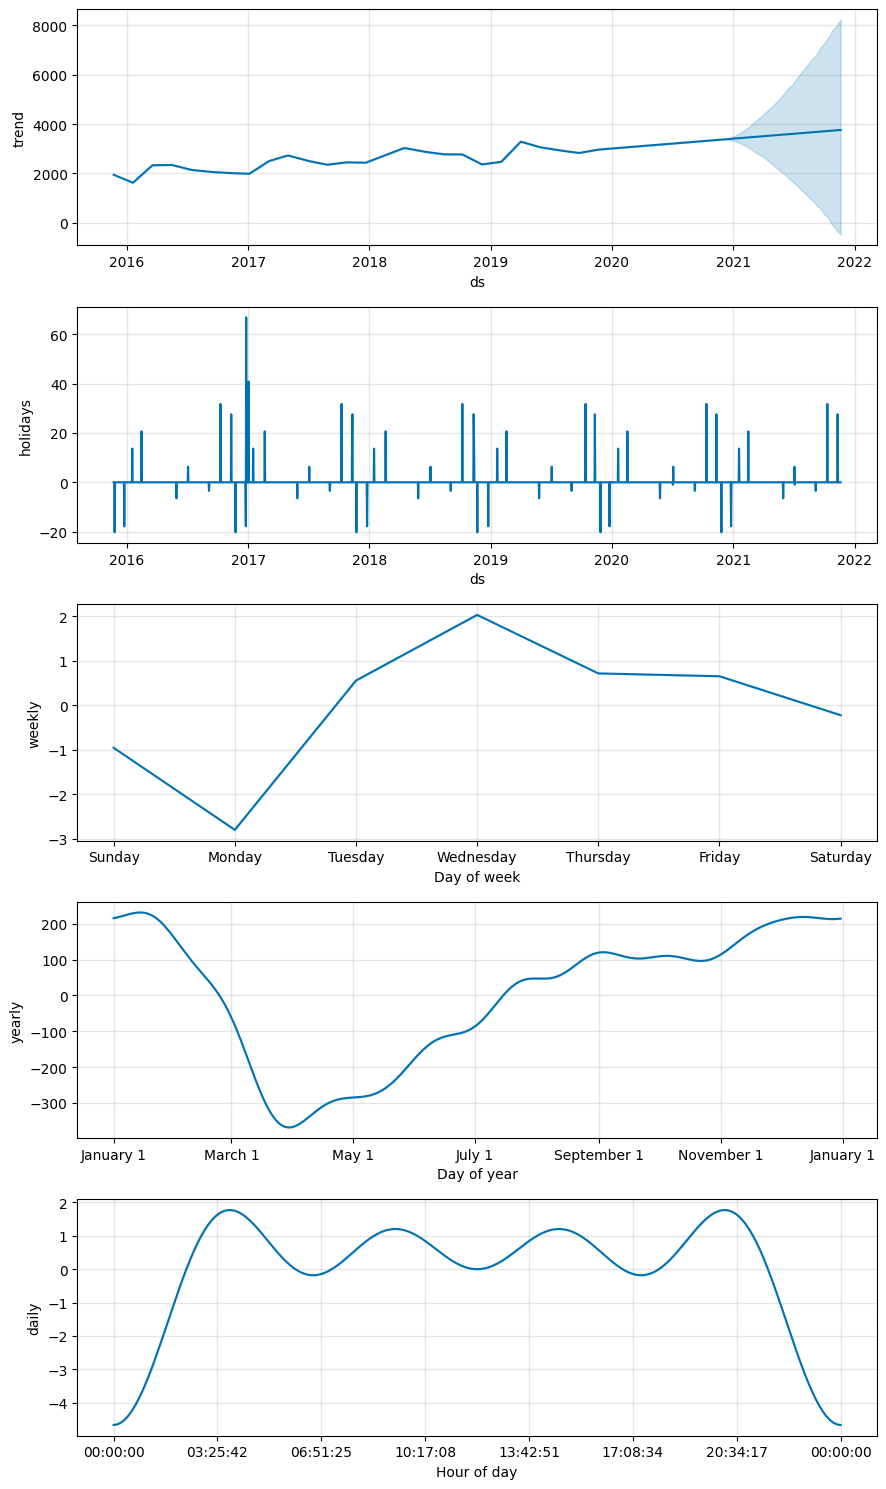

In [10]:
# Initialize Model with optimized parameters
# Best Parameters found: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01}
model = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=0.01,
    daily_seasonality=True
)
model.add_country_holidays(country_name='US')

# Training the model
model.fit(df_final)

# Create future dates for 1 year (365 days)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# Plotting the Forecast
fig1 = model.plot(forecast)
plt.title('Stock Price Forecast for Next 365 Days')
plt.show()

# Plotting Components (Trend, Weekly, Yearly)
fig2 = model.plot_components(forecast)
plt.show()

INFO:prophet:Making 5 forecasts with cutoffs between 2017-12-01 00:00:00 and 2019-11-21 00:00:00


  0%|          | 0/5 [00:00<?, ?it/s]

Performance Metrics (Head):


,horizon,mae,rmse,mape
0,37 days,57.204503,83.318911,0.020942
1,38 days,59.600668,86.212441,0.021821
2,39 days,61.474919,88.228608,0.022481
3,40 days,63.420499,90.223343,0.023161
4,41 days,65.458728,92.306805,0.023872


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


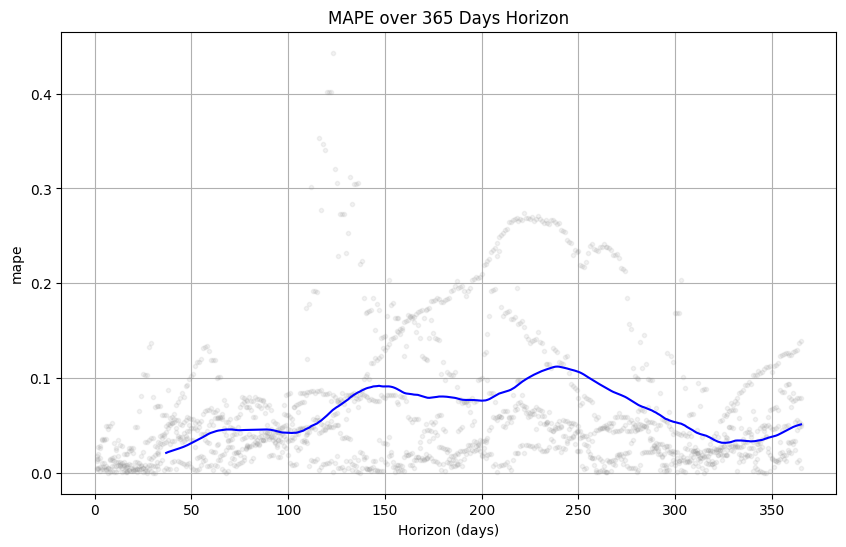

In [11]:
# Cross Validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')

# Performance Metrics
df_p = performance_metrics(df_cv)
print("Performance Metrics (Head):")
display(df_p[['horizon', 'mae', 'rmse', 'mape']].head())

# Visualize MAPE (Accuracy)
fig3 = plot_cross_validation_metric(df_cv, metric='mape')
plt.title('MAPE over 365 Days Horizon')
plt.show()